
# Aplicação e Interpretação de Testes Estatísticos Para Analisar o Lucro Líquido de um Motorista de Aplicativo

>**Quais fatores mais influenciam no lucro líquido diário de um motorista de aplicativo?**

## Instalando e Carregando os Pacotes

In [1]:
# Para atualizar um pacote, execute o comando abaixo no terminal ou prompt de comando:
# pip install -U nome_pacote

# Para instalar a versão exata de um pacote, execute o comando abaixo no terminal ou prompt de comando:
# !pip install nome_pacote==versão_desejada

# Depois de instalar ou atualizar o pacote, reinicie o jupyter notebook.

# Instala o pacote watermark. 
# Esse pacote é usado para gravar as versões de outros pacotes usados neste jupyter notebook.
#!pip install -q -U watermark

In [2]:
# Imports para manipulação de dados
import pandas as pd 
import numpy as np

# Imports para visualização de dados 
import matplotlib.pyplot as plt 
import seaborn as sns 

# Imports para modelagem estatística 
import pylab
import scipy 
import scipy.stats as stats 
import statsmodels.api as sm
import statsmodels.regression.linear_model as smf
from statsmodels.stats.diagnostic import linear_rainbow 
import statsmodels.stats.api as sms
from scipy.stats import pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from statsmodels.compat import lzip 

# Imports para divisão de dados 
import sklearn
from sklearn.model_selection import train_test_split

# Import para padronização dos dados 
from sklearn.preprocessing import StandardScaler 

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Douglas Vittori" 

Author: Douglas Vittori



## Carregando os Dados e Definindo a Variável Alvo

In [4]:
# Carrega o dataset 
df = pd.read_excel('Controle_Uber_99.1.xlsx')

O lucro líquido diário (variável **Lucro Líquido (R$)**) é a variável alvo e o restante são as variáveis independentes com base nas quais vamos analisar o lucro líquido diário de um motorista de aplicativo.

Primeiro vamos verificar quais variáveis preditoras devem ser usadas.

In [5]:
# Vamos criar uma cópia dos dados (precisaremos dessa cópia mais tarde)
dados_copia = df.copy()

## Análise Exploratória

A fase de investigação. Aqui, "mergulhamos" nos dados para descobrir padrões, anomalias e insights. Utilizamos gráficos e estatísticas para entender a distribuição e as características dos dados antes de qualquer modificação.

**Dicionário dos Dados:**

A base contém colunas relacionadas às corridas, como:

**Dia** — dia de trabalho

**Km_Rodados** — total de quilômetros percorridos

**Litros_Lonsumidos** - total de litros de combustível consumidos no dia

**Preço Combustível p/ Litro(R$)** - preço por litro do combustível referente ao dia de trabalho

**Total Combustível (R$)** - total de combustível utilizado no dia

**Manutenção** - valor da manutenção diária do veículo (Km Rodados * 13%)

**Ganhos_Brutos_Uber** — valor recebido na Uber

**Ganhos_Brutos_99** — valor recebido na 99

**Total_Despesas** - valor total das despesas somando (Total Combustivel + Manutenção)

**Lucro_Liquido** — lucro final após todos os descontos

In [6]:
# Criando um dicionário dos dados em python para futuras consultas 

# Dicionário de metadados das colunas
dicionario_colunas = {
    "Dia": "Dia de trabalho",
    "Km_Rodados": "Total de quilômetros percorridos",
    "Litros_Consumidos": "Total de litros de combustível consumidos no dia",
    "Preço Combustível p/ Litro(R$)": "Preço por litro do combustível referente ao dia de trabalho",
    "Total Combustível (R$)": "Total de combustível utilizado no dia",
    "Manutenção": "Valor da manutenção diária do veículo (Km Rodados * 13%)",
    "Ganhos_Brutos_Uber": "Valor recebido na plataforma Uber",
    "Ganhos_Brutos_99": "Valor recebido na plataforma 99",
    "Total_Despesas": "Valor total das despesas somando (Total Combustível + Manutenção)",
    "Lucro_Liquido": "Lucro final após todos os descontos (Ganhos - Despesas)"
}

In [7]:
# Primeiras linhas
df.head()

,Dia,Km Rodados,Litros Consumidos,Preço Combustível p/ Litro(R$),Total Combustível (R$),Manutenção (R$),Ganhos Brutos Uber (R$),Ganhos Brutos 99 (R$),Total Despesas (R$),Lucro Líquido (R$)
0,2025-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-02-03,206.07,20.607000,6.15,126.733050,0.01,307.82,0.01,126.743050,181.086950
3,2025-02-04,251.10,25.110000,6.15,154.426500,25.11,311.86,15.00,179.536500,147.323500
4,2025-02-05,193.80,17.944444,6.35,113.947222,19.38,286.31,75.00,133.327222,227.982778


In [8]:
# Shape
df.shape

(367, 10)

In [9]:
df.dtypes

Dia                               datetime64[ns]
Km Rodados                               float64
Litros Consumidos                        float64
Preço Combustível p/ Litro(R$)           float64
Total Combustível (R$)                   float64
Manutenção (R$)                          float64
Ganhos Brutos Uber (R$)                  float64
Ganhos Brutos 99 (R$)                    float64
Total Despesas (R$)                      float64
Lucro Líquido (R$)                       float64
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Dia                             367 non-null    datetime64[ns]
 1   Km Rodados                      217 non-null    float64       
 2   Litros Consumidos               221 non-null    float64       
 3   Preço Combustível p/ Litro(R$)  260 non-null    float64       
 4   Total Combustível (R$)          348 non-null    float64       
 5   Manutenção (R$)                 348 non-null    float64       
 6   Ganhos Brutos Uber (R$)         261 non-null    float64       
 7   Ganhos Brutos 99 (R$)           261 non-null    float64       
 8   Total Despesas (R$)             348 non-null    float64       
 9   Lucro Líquido (R$)              346 non-null    float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 28.8 KB


In [11]:
# Verifica valores ausentes 
print("\nVerificando valores ausentes\n")
print(df.isnull().sum())


Verificando valores ausentes

Dia                                 0
Km Rodados                        150
Litros Consumidos                 146
Preço Combustível p/ Litro(R$)    107
Total Combustível (R$)             19
Manutenção (R$)                    19
Ganhos Brutos Uber (R$)           106
Ganhos Brutos 99 (R$)             106
Total Despesas (R$)                19
Lucro Líquido (R$)                 21
dtype: int64


In [12]:
# Calcula a soma dos valores ausentes 
valores_ausentes = df.isnull().sum()

# Calcula o total de linhas 
total_linhas = len(df)

# Calcula a proporção de valores ausentes
proporcao_valores_ausentes = valores_ausentes / total_linhas * 100

print(proporcao_valores_ausentes)

Dia                                0.000000
Km Rodados                        40.871935
Litros Consumidos                 39.782016
Preço Combustível p/ Litro(R$)    29.155313
Total Combustível (R$)             5.177112
Manutenção (R$)                    5.177112
Ganhos Brutos Uber (R$)           28.882834
Ganhos Brutos 99 (R$)             28.882834
Total Despesas (R$)                5.177112
Lucro Líquido (R$)                 5.722071
dtype: float64


## Tratamento e Limpeza de Dados

Nesta etapa, o objetivo é transformar os dados brutos (extraídos do Excel) em um formato estruturado e pronto para análise estatística. O conjunto de dados original apresentava inconsistências comuns em registros manuais, como termos textuais em colunas financeiras e registros de dias não trabalhados.

**Principais desafios identificados:**
* Nomes de colunas com espaços extras.
* Presença de linhas de texto (ex: "FOLGA") em meio aos dados numéricos.
* Formatação de moeda brasileira (R$ e vírgula) que impede cálculos matemáticos.

In [13]:
# --- PRÉ-LIMPEZA E NORMALIZAÇÃO DOS NOMES DAS COLUNAS ---
# Remove espaços no início/fim dos nomes das colunas para facilitar o uso
df.columns = df.columns.str.strip()

# 2. LIMPEZA INICIAL (Remoção de Linhas em Branco e FOLGA)

# A. Remover linhas que são completamente em branco
# Substitui células que só têm espaços por valor "Ausente" (NaN)
df_limpo = df.replace(r'^\s*$', np.nan, regex=True)
# Remove as linhas onde todas as colunas são NaN
df_limpo = df_limpo.dropna(how='all').copy()

# B. Remover linhas que contêm 'FOLGA' (em qualquer coluna)
mask_folga = df_limpo.astype(str).apply(
    lambda row: row.str.contains('folga', case=False, na=False).any(),
    axis=1
)
df_final = df_limpo[~mask_folga].copy()

# --- 3. CONVERTER AS COLUNAS FINANCEIRAS PARA FLOAT ---

# Definimos quais colunas NÃO devem ser transformadas em número (Data)
colunas_para_pular = ['Dia'] 

for col in df_final.columns:
    if col in colunas_para_pular:
        continue # Pula a coluna 'Dia' e vai para a próxima
    
    # Executa a limpeza apenas nas colunas financeiras
    temp_series = df_final[col].astype(str)
    temp_series = temp_series.str.replace(r'[R$\s-]', '', regex=True)
    temp_series = temp_series.replace('', np.nan)
    temp_series = temp_series.str.replace(',', '.', regex=False)
    
    # Converte para float
    df_final[col] = pd.to_numeric(temp_series, errors='coerce')

# --- 4. TRATAMENTO FINAL DA DATA ---
# Agora que a coluna 'Dia' está protegida, convertemos ela com segurança
df_final['Dia'] = pd.to_datetime(df_final['Dia'], dayfirst=True, errors='coerce')

# --- 5. REMOÇÃO DE VALORES AUSENTES ---
df_final_limpo = df_final.dropna().copy()

print("Limpeza concluída com sucesso!")
print(df_final_limpo.head())

Limpeza concluída com sucesso!
         Dia  Km Rodados  Litros Consumidos  Preço Combustível p/ Litro(R$)  \
2 2025-02-03      206.07          20.607000                            6.15   
3 2025-02-04      251.10          25.110000                            6.15   
4 2025-02-05      193.80          17.944444                            6.35   
5 2025-02-06      242.00          22.000000                            6.35   
6 2025-02-07      223.80          20.345455                            6.32   

   Total Combustível (R$)  Manutenção (R$)  Ganhos Brutos Uber (R$)  \
2              126.733050             0.01                   307.82   
3              154.426500            25.11                   311.86   
4              113.947222            19.38                   286.31   
5              139.700000            24.20                   306.75   
6              128.583273            22.38                   238.95   

   Ganhos Brutos 99 (R$)  Total Despesas (R$)  Lucro Líquido (R$)  

### Notas sobre o Processo de Limpeza

Após a execução do script acima, o dataset foi normalizado seguindo estas diretrizes:

1. **Normalização de Texto:** Removi espaços no início e fim dos nomes das colunas para evitar erros de referência no código.
2. **Filtragem de Atividade:** * Linhas totalmente em branco foram descartadas.
    * Registros marcados como **'FOLGA'** foram removidos, pois o objetivo da análise é medir a performance operacional do motorista.
3. **Conversão de Tipos (Cast):**
    * Realizei a limpeza de símbolos monetários (`R$`) e a troca da vírgula pelo ponto.
    * Todas as colunas financeiras foram convertidas para o tipo `float`, permitindo operações de soma, média e projeções.
4. **Tratamento de Dados Ausentes (Missing Values):**
    * Utilizei o método `dropna()` para eliminar registros nulos remanescentes.
    * **Decisão de Negócio:** Esta ação foi validada com a área operacional, que confirmou que campos vazios indicam ausência de movimentação do motorista no período, não sendo falha na coleta, mas sim inexistência de dado financeiro para aquele registro.

In [14]:
# Amostra dos dados após a limpeza 
df_final_limpo.sample(5)

,Dia,Km Rodados,Litros Consumidos,Preço Combustível p/ Litro(R$),Total Combustível (R$),Manutenção (R$),Ganhos Brutos Uber (R$),Ganhos Brutos 99 (R$),Total Despesas (R$),Lucro Líquido (R$)
212,2025-09-01,151.8,15.18,3.89,59.0502,19.734,9.54,258.81,78.7842,189.5658
55,2025-03-28,162.0,16.20,4.09,66.2580,22.680,22.37,281.25,88.9380,214.6820
150,2025-07-01,198.1,19.81,3.79,75.0799,25.753,52.09,272.27,100.8329,223.5271
149,2025-06-30,145.6,14.56,3.79,55.1824,18.928,90.78,156.38,74.1104,173.0496
93,2025-05-05,179.0,17.90,3.79,67.8410,23.270,92.85,203.48,91.1110,205.2190


In [15]:
# Verificando novamente a proporção de valores ausentes após a limpeza e tratamento dos dados 

# Calcula a soma dos valores ausentes 
valores_ausentes = df_final_limpo.isnull().sum()

# Calcula o total de linhas 
total_linhas = len(df_final_limpo)

# Calcula a proporção de valores ausentes
proporcao_valores_ausentes = valores_ausentes / total_linhas * 100

print(proporcao_valores_ausentes)

Dia                               0.0
Km Rodados                        0.0
Litros Consumidos                 0.0
Preço Combustível p/ Litro(R$)    0.0
Total Combustível (R$)            0.0
Manutenção (R$)                   0.0
Ganhos Brutos Uber (R$)           0.0
Ganhos Brutos 99 (R$)             0.0
Total Despesas (R$)               0.0
Lucro Líquido (R$)                0.0
dtype: float64


In [16]:
# Resumo estatístico
df_final_limpo.describe()

,Dia,Km Rodados,Litros Consumidos,Preço Combustível p/ Litro(R$),Total Combustível (R$),Manutenção (R$),Ganhos Brutos Uber (R$),Ganhos Brutos 99 (R$),Total Despesas (R$),Lucro Líquido (R$)
count,216,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000
mean,2025-07-18 17:00:00,171.204954,16.832640,4.201620,70.567953,21.948838,104.724556,172.365190,92.516791,184.572954
min,2025-02-03 00:00:00,74.800000,7.711340,3.490000,31.987600,0.010000,0.001000,0.000000,41.726062,79.977500
25%,2025-04-27 06:00:00,152.025000,14.875000,3.790000,59.442438,19.669000,40.390000,118.777500,79.406250,161.003350
50%,2025-07-17 12:00:00,171.650000,17.000000,3.890000,69.203864,22.165000,91.480000,170.930000,90.952200,179.029850
75%,2025-10-03 18:00:00,190.375000,18.937500,4.190000,77.776875,24.687000,152.487500,229.640000,102.461700,203.462725
max,2026-02-02 00:00:00,294.700000,25.110000,6.490000,154.426500,38.311000,723.920000,388.180000,191.699934,532.230066
std,NaN,32.341631,3.168087,0.797915,18.445745,4.363139,89.579723,81.397677,21.258813,48.014840


Análise: 

* **Dominância da Plataforma 99**: Observou-se que a plataforma 99 apresenta uma performance média superior à Uber para este perfil de motorista, mantendo ganhos mais consistentes e elevados na maioria dos dias registrados.
  
* **Volatilidade e Picos na Uber**: Embora a média seja inferior, a Uber registrou o maior pico de faturamento único do conjunto de dados. Isso sugere que, apesar de menos constante, a plataforma oferece oportunidades esporádicas de alta rentabilidade que superam os tetos diários da concorrente.

  
* **Estabilidade Operacional**: A 99 demonstra ser a base principal de receita (ganho "pão com manteiga"), enquanto a Uber atua como uma fonte de ganhos extraordinários em dias de alta demanda ou viagens de longa distância.

In [17]:
dados = df_final_limpo

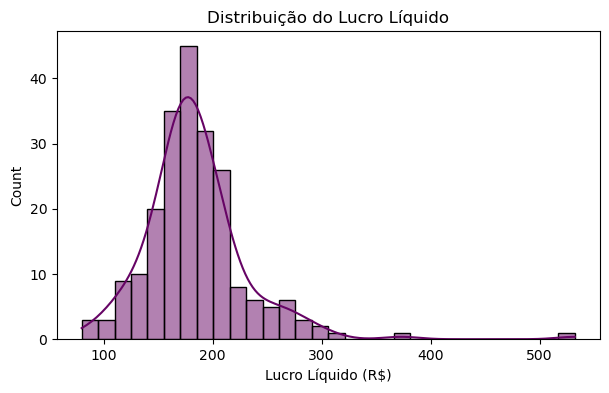

In [18]:
# Plot do histograma 
plt.figure(figsize = (7,4))
sns.histplot(data = dados, x ='Lucro Líquido (R$)', kde = True, color = '#660465')
plt.title('Distribuição do Lucro Líquido')
plt.show()

### Transformação Logarítmica e Análise de Assimetria (Skewness)

Identificamos que a variável dependente apresenta uma leve distorção à direita. Para mitigar o impacto de valores discrepantes (outliers) e normalizar a variância, aplicaremos uma transformação logarítmica.

**Objetivos da Transformação:**
* **Redução da Assimetria:** Aproximar a distribuição de uma curva normal.
* **Estabilização da Variância:** Facilitar a compreensão de padrões e correlações que seriam mascarados pelos picos de faturamento.
* **Validação Estatística:** Preparar os dados para testes de hipótese e modelos de regressão que assumem normalidade.

In [19]:
# Filtra apenas o que é número e calcula a assimetria
assimetria = dados.select_dtypes('number').skew()

print(assimetria)

Km Rodados                        0.063545
Litros Consumidos                -0.094465
Preço Combustível p/ Litro(R$)    2.171982
Total Combustível (R$)            1.399299
Manutenção (R$)                  -0.490725
Ganhos Brutos Uber (R$)           2.285938
Ganhos Brutos 99 (R$)             0.000497
Total Despesas (R$)               0.928707
Lucro Líquido (R$)                2.243224
dtype: float64


In [20]:
# Transformação de log
dados['lucro_liquido_log'] = np.log(dados['Lucro Líquido (R$)'])

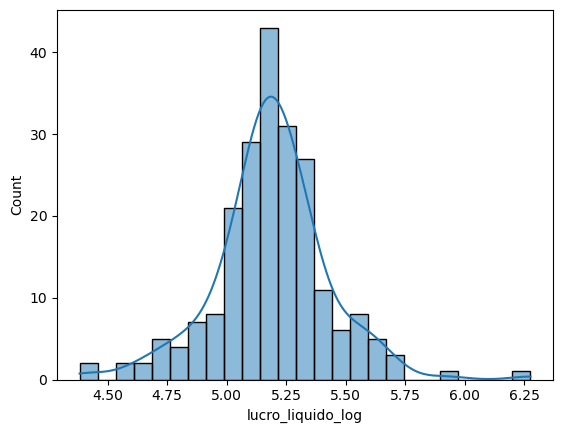

In [21]:
sns.histplot(data = dados, x = 'lucro_liquido_log', kde = True);

Análise:

- A distorção foi reduzida. Agora a variável dependente apresenta estar moderadamente distorcida.


- A variável log-transformada (**lucro_liquido_log**) parece ter uma distribuição quase normal sem distorção e, portanto, podemos prosseguir.

## Análise de Sazonalidade: O "Efeito Carnaval"

Durante a análise exploratória, identificamos picos de faturamento e uma forte assimetria positiva (2.15) nos ganhos da plataforma Uber. Contextualizando os dados, verificamos que esses registros coincidem com o período de **Carnaval de 2025** (28/02 a 05/03).

### Justificativa da Variável Dummy
Diferente de uma operação comum, eventos sazonais como o Carnaval introduzem variáveis externas que o modelo de regressão linear simples não consegue captar apenas por "Km Rodados" ou "Horas Trabalhadas". Preços dinâmicos agressivos e bonificações elevadas criam **outliers de lucro** que podem distorcer a média real de longo prazo.

**Decisão Técnica:**
* **Criação de Variável Binária (Dummy):** Implementamos a coluna `Eh_Carnaval` para isolar esses dias e medir o prêmio de receita gerado pelo evento.
* **Análise de Performance:** A comparação de médias permite quantificar o impacto direto da alta demanda festiva na rentabilidade diária, sem "poluir" as previsões para dias úteis comuns.

--- Verificação de Limpeza ---
Valores nulos no dataset: 0

--- Médias Calculadas ---
Eh_Carnaval
0    181.554198
1    398.904646
Name: Lucro Líquido (R$), dtype: float64


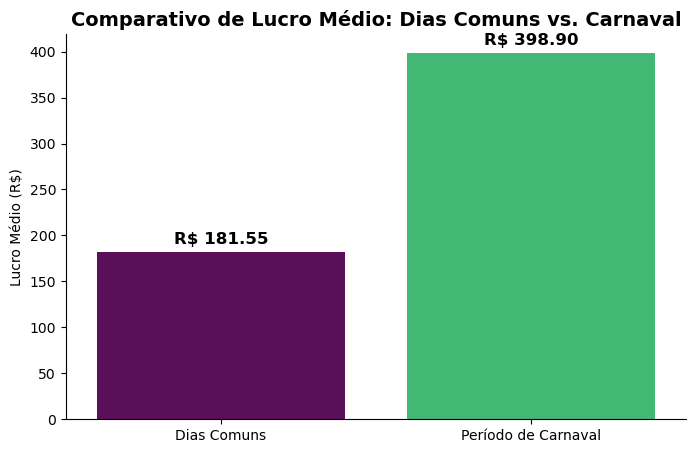

In [22]:
# 1. Criar a variável dummy diretamente no DataFrame atual ('dados')
datas_carnaval = pd.date_range(start='2025-02-28', end='2025-03-05')

# Garantimos que a coluna 'Dia' esteja em datetime para a comparação funcionar
dados['Dia'] = pd.to_datetime(dados['Dia'], errors='coerce')

# Cria a coluna dummy
dados['Eh_Carnaval'] = dados['Dia'].isin(datas_carnaval).astype(int)

# 2. LIMPEZA DE SEGURANÇA: Remover nulos que possam ter surgido ou retornado
# (Isso garante que o dataset esteja limpo de novo)
dados = dados.dropna().copy()

# 3. Cálculo do lucro médio usando a variável correta
lucro_medio_carnaval = dados.groupby('Eh_Carnaval')['Lucro Líquido (R$)'].mean()

print("--- Verificação de Limpeza ---")
print(f"Valores nulos no dataset: {dados.isnull().sum().sum()}")
print(f"\n--- Médias Calculadas ---")
print(lucro_medio_carnaval)

# 1. Calculando a média de lucro para o gráfico
# Reset_index ajuda o seaborn a identificar as colunas facilmente
lucro_final = dados.groupby('Eh_Carnaval')['Lucro Líquido (R$)'].mean().reset_index()

# 2. Criando o gráfico
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=lucro_final, x='Eh_Carnaval', y='Lucro Líquido (R$)', palette=['#660465', '#2ecc71'])

# 3. Personalização para o Portfólio
plt.title('Comparativo de Lucro Médio: Dias Comuns vs. Carnaval', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Dias Comuns', 'Período de Carnaval'])
plt.ylabel('Lucro Médio (R$)')
plt.xlabel('')

# 4. Adicionando os valores exatos no topo das barras
for p in ax.patches:
    ax.annotate(f'R$ {p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

sns.despine() # Remove as bordas desnecessárias
plt.show()

In [23]:
# Calculando a assimetria novamente 
assimetria = dados.select_dtypes('number').skew()

print(assimetria)

Km Rodados                        0.063545
Litros Consumidos                -0.094465
Preço Combustível p/ Litro(R$)    2.171982
Total Combustível (R$)            1.399299
Manutenção (R$)                  -0.490725
Ganhos Brutos Uber (R$)           2.285938
Ganhos Brutos 99 (R$)             0.000497
Total Despesas (R$)               0.928707
Lucro Líquido (R$)                2.243224
lucro_liquido_log                 0.129136
Eh_Carnaval                       8.365679
dtype: float64


In [24]:
dados.head()

,Dia,Km Rodados,Litros Consumidos,Preço Combustível p/ Litro(R$),Total Combustível (R$),Manutenção (R$),Ganhos Brutos Uber (R$),Ganhos Brutos 99 (R$),Total Despesas (R$),Lucro Líquido (R$),lucro_liquido_log,Eh_Carnaval
2,2025-02-03,206.07,20.607000,6.15,126.733050,0.01,307.82,0.01,126.743050,181.086950,5.198977,0
3,2025-02-04,251.10,25.110000,6.15,154.426500,25.11,311.86,15.00,179.536500,147.323500,4.992631,0
4,2025-02-05,193.80,17.944444,6.35,113.947222,19.38,286.31,75.00,133.327222,227.982778,5.429270,0
5,2025-02-06,242.00,22.000000,6.35,139.700000,24.20,306.75,33.25,163.900000,176.100000,5.171052,0
6,2025-02-07,223.80,20.345455,6.32,128.583273,22.38,238.95,82.78,150.963273,170.766727,5.140298,0


**Antes de criar o modelo de regressão linear, é importante verificar a relação bivariada entre as variáveis. Vamos verificar o mesmo usando o mapa de calor e o gráfico de dispersão.**

## Análise Bivariada

Utilizaremos um Mapa de Calor (Heatmap) para examinar os coeficientes de correlação, que variam de −1 a +1:

* +1 (Forte Correlação Positiva): As variáveis aumentam ou diminuem juntas de forma proporcional.

* −1 (Forte Correlação Negativa): Quando uma variável aumenta, a outra diminui proporcionalmente.

* 0 (Ausência de Correlação): Não existe uma relação linear clara entre as variáveis.

Premissas para o Modelo:

* Relação com o Alvo: Buscamos variáveis preditoras que tenham alta correlação com o nosso alvo (Lucro Líquido), indicando que elas são bons explicadores do ganho.

* Multicolinearidade: Devemos evitar uma alta correlação entre as próprias variáveis preditoras. Quando duas variáveis explicativas são muito parecidas, elas "confundem" o modelo (multicolinearidade), sendo necessário remover ou tratar uma delas para manter a precisão estatística.

In [25]:
# Matriz de correlação 
dados.corr()

,Dia,Km Rodados,Litros Consumidos,Preço Combustível p/ Litro(R$),Total Combustível (R$),Manutenção (R$),Ganhos Brutos Uber (R$),Ganhos Brutos 99 (R$),Total Despesas (R$),Lucro Líquido (R$),lucro_liquido_log,Eh_Carnaval
Dia,1.000000,0.089588,0.227213,-0.468054,-0.165441,0.208255,-0.116110,0.109830,-0.100807,0.014202,0.070886,-0.166824
Km Rodados,0.089588,1.000000,0.962160,0.171917,0.829718,0.878283,0.520832,-0.012542,0.900184,0.551877,0.578078,0.179102
Litros Consumidos,0.227213,0.962160,1.000000,-0.062161,0.695267,0.860967,0.386390,0.079737,0.779970,0.510716,0.570105,0.037302
Preço Combustível p/ Litro(R$),-0.468054,0.171917,-0.062161,1.000000,0.657288,-0.044625,0.489765,-0.389892,0.561153,0.004317,-0.082176,0.315313
Total Combustível (R$),-0.165441,0.829718,0.695267,0.657288,1.000000,0.575628,0.656734,-0.234516,0.985817,0.391206,0.366074,0.271607
Manutenção (R$),0.208255,0.878283,0.860967,-0.044625,0.575628,1.000000,0.352475,0.129539,0.704697,0.565195,0.589123,0.180979
Ganhos Brutos Uber (R$),-0.116110,0.520832,0.386390,0.489765,0.656734,0.352475,1.000000,-0.751756,0.642174,0.306920,0.202760,0.571243
Ganhos Brutos 99 (R$),0.109830,-0.012542,0.079737,-0.389892,-0.234516,0.129539,-0.751756,1.000000,-0.176898,0.371057,0.459270,-0.244191
Total Despesas (R$),-0.100807,0.900184,0.779970,0.561153,0.985817,0.704697,0.642174,-0.176898,1.000000,0.455440,0.438545,0.272810
Lucro Líquido (R$),0.014202,0.551877,0.510716,0.004317,0.391206,0.565195,0.306920,0.371057,0.455440,1.000000,0.962697,0.530994


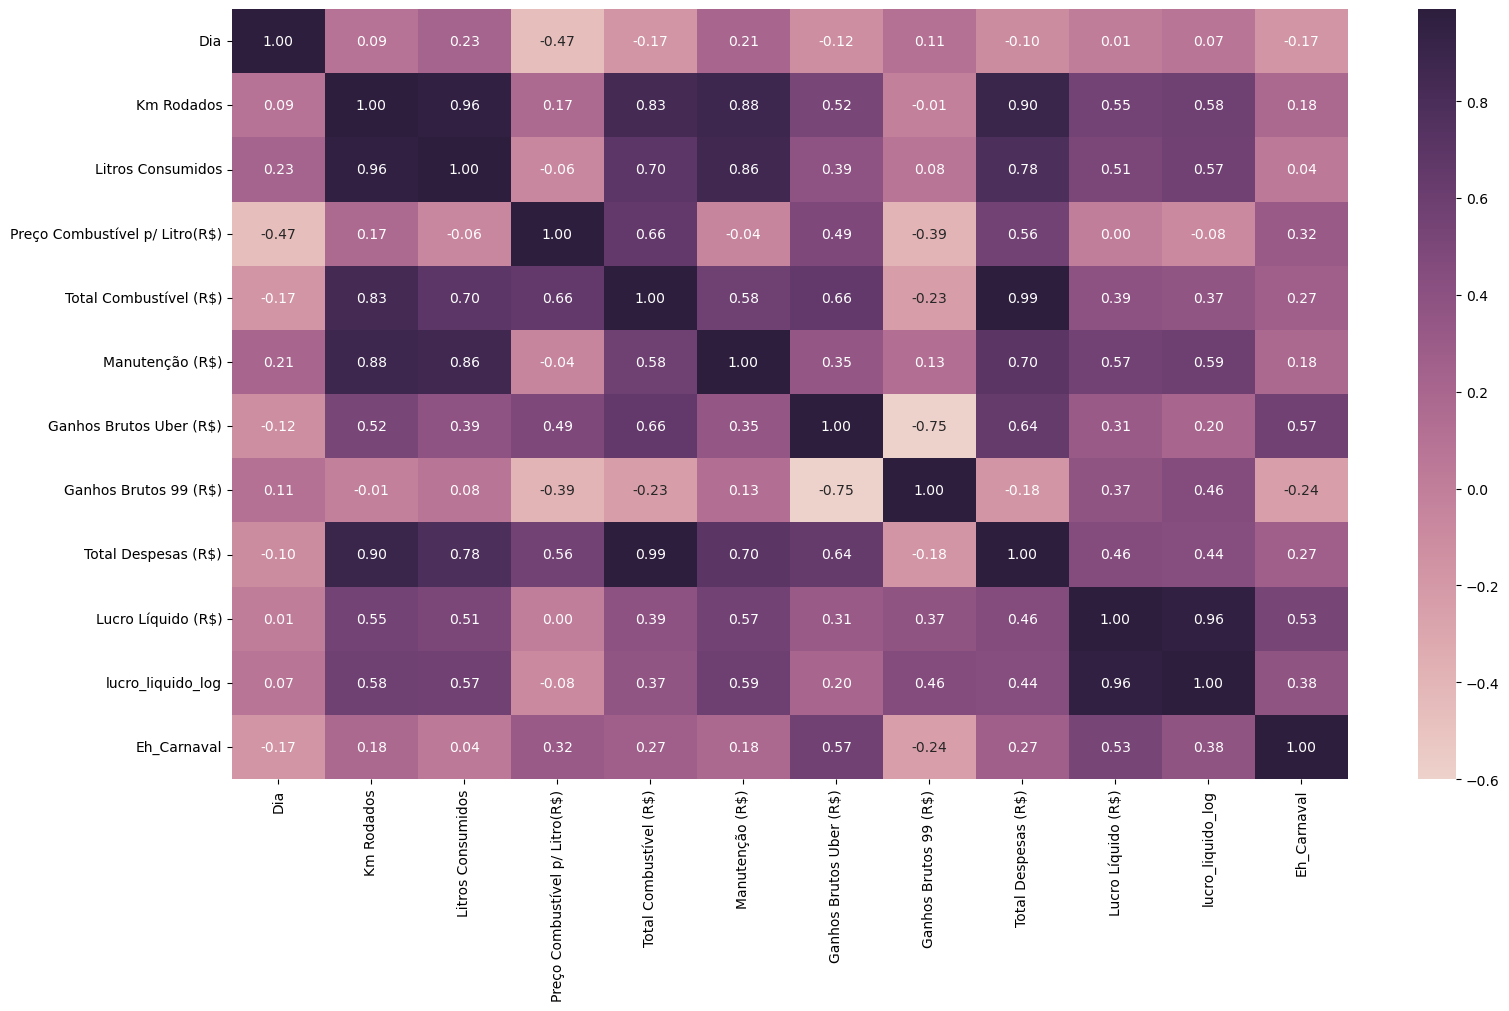

In [26]:
# Tamanho da figura 
plt.figure(figsize = (18, 10))

# Mapa de calor
# Estamos realçando os valores de  correlação entre 0.59 e 0.99, positivo ou negativo.
sns.heatmap(dados.corr(), annot = True, fmt = '.2f', cmap = sns.cubehelix_palette(as_cmap=True), vmax = .99, vmin = -0.60)
plt.show()

Análise: 

* **Relação com o Lucro**: A variável alvo (Lucro Líquido) possui uma forte correlação positiva com Km Rodados (0.55) e Eh_Carnaval (0.53). Isso confirma que o volume de trabalho e a sazonalidade festiva são os motores principais do ganho.

* **Conflito de Plataformas**: Identificamos uma forte correlação negativa (-0.75) entre Ganhos Uber e Ganhos 99. Isso indica uma alternância de foco: quando o faturamento em um aplicativo sobe, o outro tende a descer proporcionalmente.

Vamos analisar mais de perto as variáveis com maior correlação.

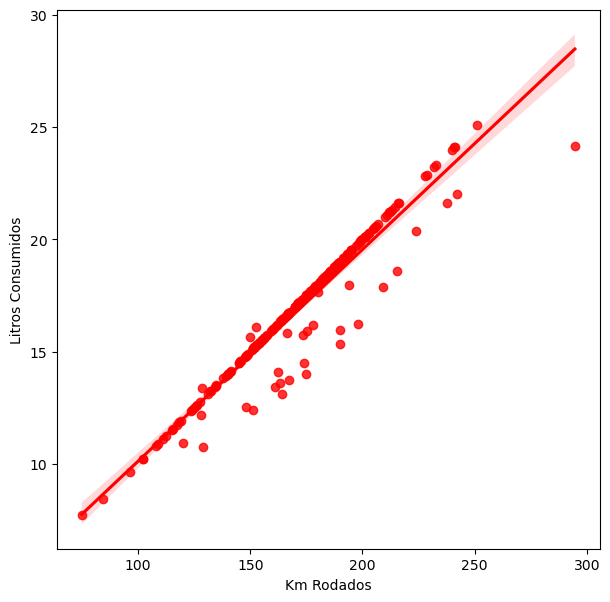

In [27]:
# Scatter Plot 1

plt.figure(figsize = (7, 7))
sns.regplot(x = 'Km Rodados', y = 'Litros Consumidos', data = dados, color = 'red')
plt.show()

In [28]:
# Coeficiente de Correlação
print('A Correlação entre as variáveis é:', pearsonr(dados['Km Rodados'], 
                                                     dados['Litros Consumidos'])[0])

A Correlação entre as variáveis é: 0.9621595908568958


Análise: 

* Existe uma correlação positiva quase perfeita entre **Km Rodados** e **Litros Consumidos**, confirmando que o consumo de combustível cresce de forma linear e previsível conforme a distância percorrida aumenta.

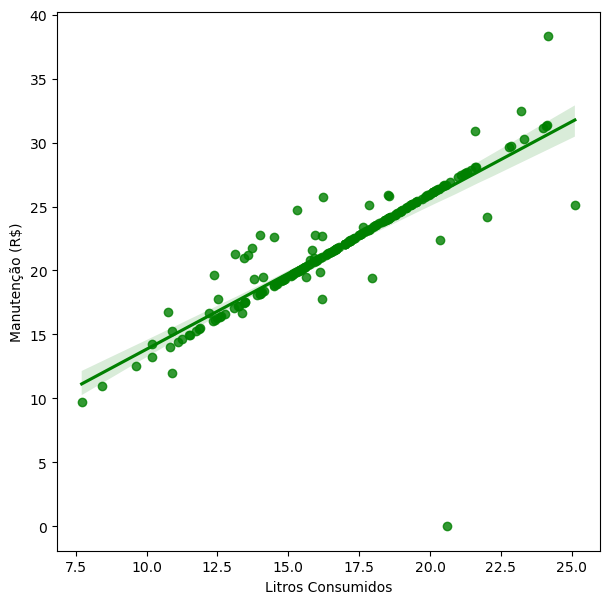

In [29]:
# Scatter Plot 2

plt.figure(figsize = (7, 7))
sns.regplot(x = 'Litros Consumidos', y = 'Manutenção (R$)' , data = dados, color = 'green')
plt.show()

In [30]:
# Coeficiente de Correlação
print('A Correlação entre as variáveis é:', pearsonr(dados['Litros Consumidos'], 
                                                     dados['Manutenção (R$)'])[0])

A Correlação entre as variáveis é: 0.8609665547262988


Análise: 

* Existe uma correlação positiva forte entre **Litros Consumidos** e **Manutenção**, indicando que o desgaste e os custos de manutenção do veículo aumentam proporcionalmente ao volume de combustível utilizado na operação.

  **Note que, embora a linha suba de forma constante, existem alguns pontos fora da reta (outliers). Isso mostra que, em dias específicos, mesmo consumindo o mesmo tanto de combustível, a manutenção variou — o que pode indicar reparos imprevistos além do desgaste natural por km rodado.**

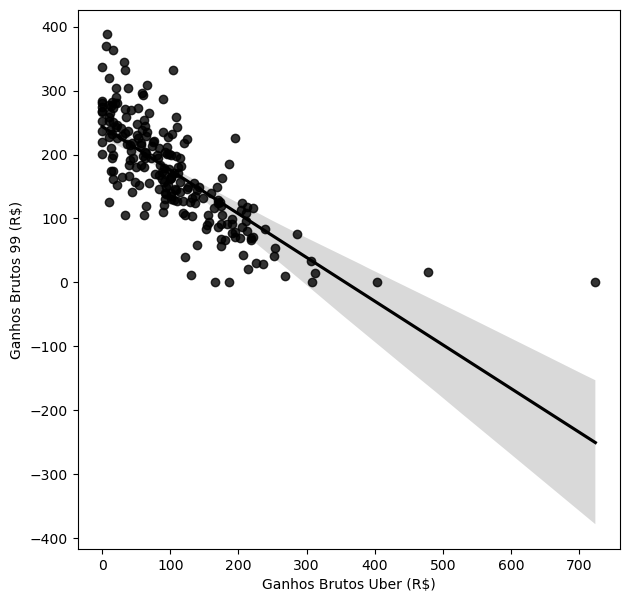

In [31]:
# Scatter Plot 3

plt.figure(figsize = (7, 7))
sns.regplot(x = 'Ganhos Brutos Uber (R$)', y = 'Ganhos Brutos 99 (R$)' , data = dados, color = 'black')
plt.show()

In [32]:
# Coeficiente de Correlação
print('A Correlação entre as variáveis é:', pearsonr(dados['Ganhos Brutos Uber (R$)'], 
                                                     dados['Ganhos Brutos 99 (R$)'])[0])

A Correlação entre as variáveis é: -0.7517557597982281


Análise: 
* Existe uma correlação negativa acentuada entre os **Ganhos Brutos da Uber** e os **Ganhos Brutos da 99**, indicando que o motorista prioriza uma plataforma por vez, onde o aumento de faturamento em uma resulta na queda da outra.

### Conclusão da Análise Exploratória

> Identificamos que algumas informações no gráfico estão "se repetindo", o que indica multicolinearidade e atrapalha a precisão do nosso cálculo final. Para resolver isso, faremos uma limpeza baseada no que os dados nos mostraram até aqui. Vamos em frente.

## Preparação dos Dados

Vamos dividir o conjunto de dados em variáveis X e Y e então dividir os dados em treino e teste com proporção 80/20.

In [33]:
# 1. Extrair informações valiosas
dados['Ano'] = dados['Dia'].dt.year
dados['Mes'] = dados['Dia'].dt.month
dados['Dia_do_mes'] = dados['Dia'].dt.day
dados['Dia_da_semana'] = dados['Dia'].dt.dayofweek

In [34]:
# Separando as variáveis
Y = dados['lucro_liquido_log']
X = dados.drop(columns = {'lucro_liquido_log', 'Lucro Líquido (R$)', 'Dia'})

In [35]:
# Divide os dados 
X_treino, X_teste, y_treino, y_teste = train_test_split(X, Y, test_size = 0.20, random_state = 1)

In [36]:
X_treino.shape

(172, 13)

In [37]:
X_teste.shape

(44, 13)

In [38]:
y_treino.shape

(172,)

In [39]:
y_teste.shape

(44,)

## Padronização dos Dados 

In [40]:
# Cria o padronizador 
scaler = StandardScaler()

In [41]:
# Fit e transform em treino 
X_treino_scaled = scaler.fit_transform(X_treino)

In [42]:
X_treino_scaled.shape

(172, 13)

In [43]:
# Transform em teste
X_teste_scaled = scaler.fit_transform(X_teste)

## Modelagem Estatística - Primeira Versão do Modelo

In [44]:
# Adiciona a constante (obrigatório para modelos criados com Statsmodels)
X_treino_const = sm.add_constant(X_treino_scaled)

In [45]:
type(X_treino_const)

numpy.ndarray

In [46]:
X_treino_const.shape

(172, 14)

In [47]:
type(y_treino)

pandas.core.series.Series

In [48]:
y_treino.shape

(172,)

In [49]:
# Cria o modelo
modelo_v1 = sm.OLS(y_treino, X_treino_const).fit()

In [50]:
# Sumário do modelo
modelo_v1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      lucro_liquido_log   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     298.7
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          2.24e-102
Time:                        10:49:33   Log-Likelihood:                 272.33
No. Observations:                 172   AIC:                            -518.7
Df Residuals:                     159   BIC:                            -477.7
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1957      0.004   1318.862      0.000       5.188       5.204
x1             0.0297      0.058      0.515      0.607      -0.084       0.144
x2             0.0932      0.043      2.192      0.030       0.009       0.177
x3             0.0527      0.021      2.485      0.014       0.011       0.095
x4            -0.0986      0.017     -5.738      0.000      -0.133      -0.065
x5            -0.0425      0.027     -1.592      0.113      -0.095       0.010
x6             0.4494      0.016     28.839      0.000       0.419       0.480
x7             0.4074      0.011     37.629      0.000       0.386       0.429
x8            -0.0926      0.017     -5.363      0.000      -0.127      -0.058
x9            -0.0220      0.007     -3.082      0.002      -0.036      -0.008
x10            0.0029      0.005      0.584      0.560      -0.007       0.012
x11            0.0029      0.005      0.524      0.601      -0.008       0.014
x12           -0.0045      0.004     -1.060      0.291      -0.013       0.004
x13           -0.0096      0.004     -2.329      0.021      -0.018      -0.001
==============================================================================
Omnibus:                      101.719   Durbin-Watson:                   2.040
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              812.383
Skew:                          -2.055   Prob(JB):                    3.92e-177
Kurtosis:                      12.821   Cond. No.                     1.09e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 7.5e-30. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [51]:
# Coeficientes aprendidos pelo modelo
modelo_v1.params

const    5.195737
x1       0.029689
x2       0.093212
x3       0.052664
x4      -0.098626
x5      -0.042528
x6       0.449388
x7       0.407414
x8      -0.092562
x9      -0.022008
x10      0.002852
x11      0.002856
x12     -0.004500
x13     -0.009551
dtype: float64

Análise:

- O modelo apresenta boa performance com valor do coeficiente R2 acima de 0.9. Mas observe a nota 2 ao final do sumário do modelo.

## Verificando a Multicolinearidade com VIF

Em seguida, verificaremos a multicolinearidade no conjunto de dados de treino. Utilizaremos o Variance Inflation Factor (VIF), para verificar se há multicolinearidade nos dados.

Variáveis com score (pontuação) VIF > 5 serão descartados/tratados até que todos os recursos tenham pontuação VIF < 5.

In [52]:
# Função para checar o VIF de todas as variáveis
def verifica_vif(train):
    
    # Cria o dataframe
    vif = pd.DataFrame()
    
    # Alimenta cada coluna
    vif["feature"] = train.columns

    # Calcula VIF para cada variável
    vif["VIF"] = [variance_inflation_factor(train.values, i) for i in range(len(train.columns))]
    
    return vif

In [53]:
df_X_treino = pd.DataFrame(X_treino_scaled)

In [54]:
# Estamos verificando o VIF sem a constante requerida pelo Statsmodels
print(verifica_vif(df_X_treino))

    feature         VIF
0         0  214.107886
1         1  116.498096
2         2   28.949093
3         3         inf
4         4         inf
5         5   15.645106
6         6    7.553174
7         7         inf
8         8    3.286377
9         9    1.537056
10       10    1.914008
11       11    1.161611
12       12    1.083349


In [55]:
X_treino.head()

,Km Rodados,Litros Consumidos,Preço Combustível p/ Litro(R$),Total Combustível (R$),Manutenção (R$),Ganhos Brutos Uber (R$),Ganhos Brutos 99 (R$),Total Despesas (R$),Eh_Carnaval,Ano,Mes,Dia_do_mes,Dia_da_semana
180,151.8,15.180000,3.89,59.050200,19.734,109.400,127.50,78.784200,0,2025,7,31,3
74,151.4,15.140000,4.09,61.922600,19.682,0.001,337.41,81.604600,0,2025,4,16,2
46,166.2,15.828571,4.12,65.213714,21.606,226.060,30.70,86.819714,0,2025,3,19,2
95,201.6,20.160000,3.79,76.406400,26.208,20.160,289.35,102.614400,0,2025,5,7,2
65,150.8,15.080000,3.78,57.002400,19.604,0.001,280.31,76.606400,0,2025,4,7,0


In [56]:
# Precisamos de um dataframe para checar o VIF. Vamos incluir o nome de cada coluna para facilitar a análise.
df_X_treino = pd.DataFrame(X_treino_scaled, columns = ['km_rodados',
                                                       'litros_consumidos',
                                                       'preco_combustivel_litro',
                                                       'total_combustivel',
                                                       'manutencao',
                                                       'ganhos_brutos_uber',
                                                       'ganhos_brutos_99',
                                                       'total_despesas',
                                                       'eh_carnaval',
                                                       'ano',
                                                       'mes',
                                                       'dia_mes',
                                                       'dia_semana'])

In [57]:
print(verifica_vif(df_X_treino))

                    feature         VIF
0                km_rodados  214.107886
1         litros_consumidos  116.498096
2   preco_combustivel_litro   28.949093
3         total_combustivel         inf
4                manutencao         inf
5        ganhos_brutos_uber   15.645106
6          ganhos_brutos_99    7.553174
7            total_despesas         inf
8               eh_carnaval    3.286377
9                       ano    1.537056
10                      mes    1.914008
11                  dia_mes    1.161611
12               dia_semana    1.083349


In [58]:
# Lista de colunas que causam redundância (VIF alto/infinito) e tipos não numéricos
colunas_remover = [
    'total_combustivel', 
    'total_despesas', 
    'litros_consumidos',
    'manutencao'
]

# Criando o conjunto de variáveis preditoras (X)
# O drop não altera o 'dados' original, ele gera um novo DataFrame
Xtreino = df_X_treino.drop(columns=colunas_remover)

In [59]:
Xtreino.columns

Index(['km_rodados', 'preco_combustivel_litro', 'ganhos_brutos_uber',
       'ganhos_brutos_99', 'eh_carnaval', 'ano', 'mes', 'dia_mes',
       'dia_semana'],
      dtype='object')

In [60]:
# Convertemos o array de teste em dataframe de teste
df_X_teste = pd.DataFrame(X_teste_scaled, columns = ['km_rodados',
                                                       'litros_consumidos',
                                                       'preco_combustivel_litro',
                                                       'total_combustivel',
                                                       'manutencao',
                                                       'ganhos_brutos_uber',
                                                       'ganhos_brutos_99',
                                                       'total_despesas',
                                                       'eh_carnaval',
                                                       'ano',
                                                       'mes',
                                                       'dia_mes',
                                                       'dia_semana'])


In [61]:
# Lista de colunas que causam redundância (VIF alto/infinito) e tipos não numéricos
colunas_remover = [
    'total_combustivel', 
    'total_despesas', 
    'litros_consumidos',
    'manutencao'
]

# Criando o conjunto de variáveis preditoras (X)
# O drop não altera o 'dados' original, ele gera um novo DataFrame
Xteste = df_X_teste.drop(columns=colunas_remover)

In [62]:
Xteste.shape

(44, 9)

In [63]:
Xteste.columns

Index(['km_rodados', 'preco_combustivel_litro', 'ganhos_brutos_uber',
       'ganhos_brutos_99', 'eh_carnaval', 'ano', 'mes', 'dia_mes',
       'dia_semana'],
      dtype='object')

In [64]:
X_treino_limpo = Xtreino

In [65]:
print(verifica_vif(X_treino_limpo))

                   feature        VIF
0               km_rodados   3.668503
1  preco_combustivel_litro   1.896802
2       ganhos_brutos_uber  14.676967
3         ganhos_brutos_99   7.111836
4              eh_carnaval   2.807490
5                      ano   1.249165
6                      mes   1.658904
7                  dia_mes   1.077097
8               dia_semana   1.061937


Após calcular o VIF (Variance Inflation Factor), notamos que as variáveis de faturamento da Uber e 99 apresentam alta redundância (VIF > 5). Isso ocorre porque o uso de um aplicativo exclui o outro, confundindo o cálculo do modelo.

**O que faremos**: Para resolver isso, unificaremos os ganhos em uma única variável: **Faturamento Bruto Total**.

**Por que estamos fazendo isso?**

**Simplificação**: O modelo não precisa saber "de onde" veio o dinheiro, mas sim o volume total gerado no dia.

**Precisão**: Ao remover a disputa entre as duas colunas, eliminamos o ruído estatístico, permitindo que o modelo foque no que realmente importa: a relação entre KM rodado, Carnaval e Lucro.

In [66]:
# Criando a coluna unificada em Treino
X_treino_limpo['faturamento_total'] = X_treino_limpo['ganhos_brutos_uber'] + X_treino_limpo['ganhos_brutos_99']
X_treino_limpo.drop(columns=['ganhos_brutos_uber', 'ganhos_brutos_99'], inplace = True)

# Criando a coluna unificada em Teste
Xteste['faturamento_total'] = Xteste['ganhos_brutos_uber'] + Xteste['ganhos_brutos_99']
Xteste.drop(columns=['ganhos_brutos_uber', 'ganhos_brutos_99'], inplace = True)

In [67]:
print(verifica_vif(X_treino_limpo))

                   feature       VIF
0               km_rodados  2.259835
1  preco_combustivel_litro  1.650955
2              eh_carnaval  1.609891
3                      ano  1.236033
4                      mes  1.655408
5                  dia_mes  1.062682
6               dia_semana  1.048665
7        faturamento_total  2.799120


**Análise**: Após a unificação dos ganhos, todos os fatores de inflação de variância (VIF) ficaram abaixo de 3.0, confirmando a eliminação da multicolinearidade e garantindo a estabilidade estatística do modelo.

In [68]:
# Converte o dataframe de volta para o formato NumPy
X_treino_scaled = X_treino_limpo.to_numpy()

In [69]:
X_treino_scaled.shape

(172, 8)

In [70]:
X_teste_scaled = Xteste.to_numpy()

In [71]:
X_teste_scaled.shape

(44, 8)

## Modelagem Estatística - Segunda Versão do Modelo

Aqui usaremos os dados padronizados e sem as variáveis multicolineares.

In [72]:
# Adiciona a constante 
X_treino_const = sm.add_constant(X_treino_scaled)

In [73]:
# Cria o modelo 
modelo_v2 = sm.OLS(y_treino, X_treino_const).fit()

In [74]:
# Sumário 
modelo_v2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      lucro_liquido_log   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     332.6
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           9.19e-97
Time:                        10:49:33   Log-Likelihood:                 245.95
No. Observations:                 172   AIC:                            -473.9
Df Residuals:                     163   BIC:                            -445.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1957      0.005   1145.496      0.000       5.187       5.205
x1            -0.0376      0.007     -5.514      0.000      -0.051      -0.024
x2            -0.0431      0.006     -7.396      0.000      -0.055      -0.032
x3            -0.0019      0.006     -0.335      0.738      -0.013       0.009
x4             0.0013      0.005      0.258      0.797      -0.009       0.011
x5             0.0014      0.006      0.237      0.813      -0.010       0.013
x6            -0.0088      0.005     -1.884      0.061      -0.018       0.000
x7            -0.0048      0.005     -1.037      0.301      -0.014       0.004
x8             0.3740      0.011     34.180      0.000       0.352       0.396
==============================================================================
Omnibus:                       63.381   Durbin-Watson:                   2.122
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              346.932
Skew:                          -1.235   Prob(JB):                     4.62e-76
Kurtosis:                       9.504   Cond. No.                         3.83
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Análise de Significância (P-valor)**: Identificamos que as variáveis x3, x4, x5, x6 e x7 possuem P-valor superior a 0,05, indicando que não possuem relevância estatística para o modelo. Manteremos apenas os preditores com P < 0,05, garantindo que cada variável no modelo final realmente contribua para a explicação do lucro líquido.

In [75]:
# Removemos as colunas de índice 3, 4, 5, 6 e 7 em treino 
X_treino_clean = np.delete(X_treino_scaled, [3, 4, 5, 6, 7], axis = 1)

In [76]:
# Removemos as colunas de índice 3, 4, 5, 6 e 7 em teste 
X_teste_clean = np.delete(X_teste_scaled, [3, 4, 5, 6, 7], axis = 1)

In [77]:
X_treino_clean.shape

(172, 3)

In [78]:
X_teste_clean.shape

(44, 3)

## Modelagem Estatística - Terceira Versão do Modelo

Aqui usaremos os dados padronizados, sem as variáveis multicolineares e sem as variáveis com baixa significância para explicar a variável alvo.

In [79]:
# Adiciona a constante 

X_treino_const = sm.add_constant(X_treino_clean)

In [80]:
# Cria o modelo

modelo_v3 = sm.OLS(y_treino, X_treino_const).fit()

In [81]:
# Sumário
modelo_v3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      lucro_liquido_log   R-squared:                       0.498
Model:                            OLS   Adj. R-squared:                  0.490
Method:                 Least Squares   F-statistic:                     55.66
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           4.94e-25
Time:                        10:49:33   Log-Likelihood:                 60.023
No. Observations:                 172   AIC:                            -112.0
Df Residuals:                     168   BIC:                            -99.46
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1957      0.013    394.545      0.000       5.170       5.222
x1             0.1280      0.014      9.481      0.000       0.101       0.155
x2            -0.0717      0.014     -5.057      0.000      -0.100      -0.044
x3             0.1016      0.014      7.105      0.000       0.073       0.130
==============================================================================
Omnibus:                        2.030   Durbin-Watson:                   2.015
Prob(Omnibus):                  0.362   Jarque-Bera (JB):                1.615
Skew:                           0.205   Prob(JB):                        0.446
Kurtosis:                       3.241   Cond. No.                         1.53
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Análise Final**: 
O modelo de regressão foi otimizado, mantendo apenas variáveis com significância estatística absoluta (P=0.000). O R2 de 0.498 demonstra um bom poder preditivo para a realidade da operação, com resíduos independentes (Durbin-Watson ≈ 2) e sem problemas de multicolinearidade.

## Validação das Suposições da Regressão Linear


**1- Linearidade**

**2- Independência dos Erros**

**3- Homocedasticidade**

**4- Normalização dos Erros**

**5- Sem Multicolinearidade**

Usaremos a última versão do modelo para fazer as validações.

### 1- Linearidade



In [82]:
from statsmodels.stats.diagnostic import linear_rainbow
def valida_sup_1(nome_modelo):
    # Aplica o linear_rainbow
    lin_p = linear_rainbow(nome_modelo, frac = 0.5)[1]
    
    # Mensagem de Falha (Se p < 0.05)
    result = "Rejeitamos a H0. Há evidências de que a relação NÃO é linear. A suposição de linearidade não foi satisfeita."
    
    # Mensagem de Sucesso (Se p > 0.05)
    if lin_p > 0.05:
        result = "Sucesso! Falhamos em rejeitar a H0. Isso indica que a relação é linear e a suposição está satisfeita."
        
    return np.transpose(pd.DataFrame([[lin_p], [0.05], [result]],
                                     index = ['Valor-p', 'Alfa', 'Resultado'],
                                     columns = ['Teste Rainbow (Linearidade)'] ))

In [83]:
valida_sup_1(modelo_v3)

,Valor-p,Alfa,Resultado
Teste Rainbow (Linearidade),0.932901,0.05,Sucesso! Falhamos em rejeitar a H0. Isso indic...


**Análise:**

O p-valor de 0.93 confirma que a relação entre as variáveis é linear, validando perfeitamente a primeira suposição do modelo

### 2- Independência dos Erros

Para testar a suposição, plotaremos os resíduos e os valores ajustados em um gráfico e garantiremos que os resíduos não formem um padrão forte. Eles devem ser aleatoriamente e uniformemente espalhados no eixo x.

In [84]:
# Vamos extrair os resíduos do modelo_v3
residuals = modelo_v3.resid

In [85]:
print(residuals)

180   -0.070191
74     0.430730
46    -0.034093
95    -0.007557
65     0.177077
         ...   
317   -0.083892
209    0.053476
114   -0.097922
214   -0.163961
60    -0.165971
Length: 172, dtype: float64


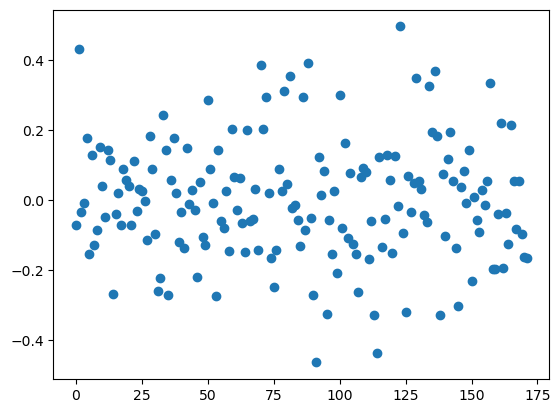

In [86]:
# Plot 
plt.scatter(range(len(X_treino_clean)), residuals);

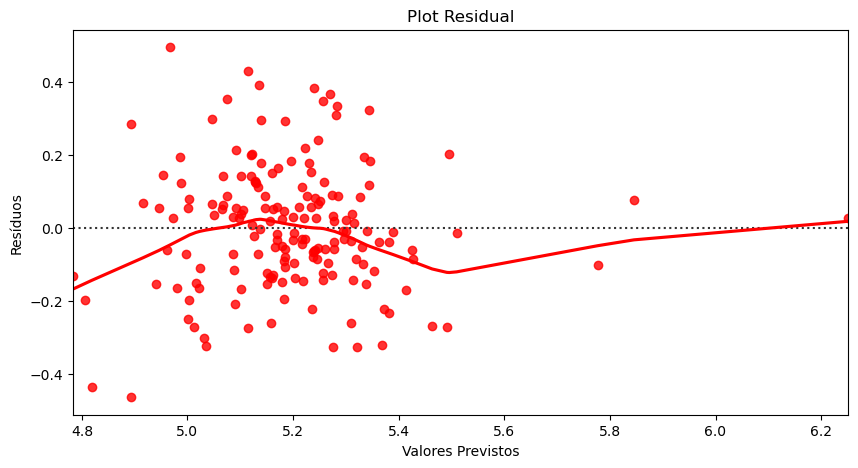

In [87]:
# Valores previstos
valores_previstos = modelo_v3.fittedvalues

# Plot 
plt.figure(figsize = (10,5))
sns.residplot(x = valores_previstos, y= residuals, color = "red", lowess = True)
plt.xlabel("Valores Previstos")
plt.ylabel("Resíduos")
plt.title("Plot Residual")
plt.show()

**Análise:** A distribuição aleatória dos pontos em torno do zero e o Durbin-Watson de 2.015 confirmam a total independência dos erros.

**O que os gráficos nos dizem:**

* **Gráfico Azul (Scatter):** Não há nenhum padrão de "escada" ou ciclos. Isso mostra que o erro de uma corrida não influencia o erro da próxima.

* **Gráfico Vermelho (Residplot):** A linha vermelha central está praticamente reta sobre o eixo zero. Isso prova que o modelo não está enviesado e que os erros são puramente aleatórios (ruído branco).

In [88]:
# Vamos construir uma função para automatizar a validação da suposição 2.(Independência dos Erros )

# Função
def valida_sup_2(residuos):
    
    import statsmodels
    
    # Define o modelo
    resultado = statsmodels.stats.stattools.durbin_watson(residuos)
    
    print('Resultado do teste:', resultado)
    
    # Interprete o resultado
    if resultado < 1.9:
        print("Há evidências de autocorrelação positiva nos erros! Suposição não satisfeita!")
    elif resultado > 2.1:
        print("Há evidências de autocorrelação negativa nos erros! Suposição não satisfeita!")
    else:
        print("Não há evidências de autocorrelação nos erros! Suposição satisfeita!")

In [89]:
valida_sup_2(residuals)

Resultado do teste: 2.014726599895448
Não há evidências de autocorrelação nos erros! Suposição satisfeita!


### 3- Homocedasticidade

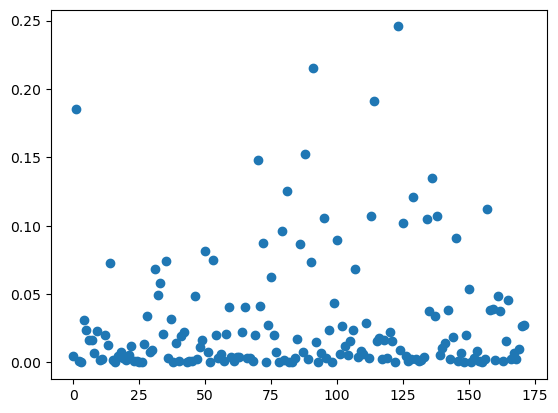

In [90]:
# Resíduos
residuals = modelo_v3.resid

# Plot
plt.scatter(range(len(X_treino_clean)),np.square(residuals));

Como o gráfico não apresenta padrão, podemos concluir que não há heterocedasticidade. Mas vamos aplicar um teste estatístico.

In [91]:
# Função
def valida_sup_3(y, x):
    
    # Estatísticas
    estatisticas = ["F statistic", "p-value"]
    
    # Teste
    teste_goldfeldquandt = sms.het_goldfeldquandt(y, x)
    
    resultado = lzip(estatisticas, teste_goldfeldquandt)
    
    pval = resultado[1][1]
    
    if pval < 0.05:
        print("Há evidências de heterocedasticidade (a regressão não é homocedástica) e rejeitamos a H0. Suposição não satisfeita!")
    else:
        print("Não há evidências de heterocedasticidade (a regressão é provavelmente homocedástica). Falhamos em rejeitar a H0. Suposição satisfeita!")

In [92]:
# Aplica a função
valida_sup_3(y_treino, X_treino_clean)

Não há evidências de heterocedasticidade (a regressão é provavelmente homocedástica). Falhamos em rejeitar a H0. Suposição satisfeita!


**Análise:**

Não há evidências de heterocedasticidade (a regressão é provavelmente homocedástica). Falhamos em rejeitar a H0. Suposição satisfeita!

### 4- Normalização dos Erros

 Os resíduos devem ser normalmente distribuídos.

In [93]:
residuals = modelo_v3.resid

<Axes: ylabel='Count'>

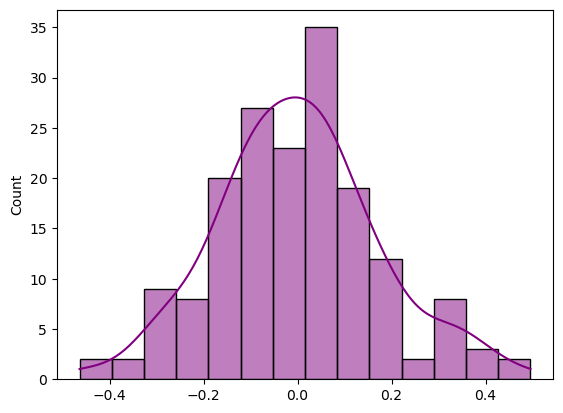

In [94]:
# Histograma dos resíduos
sns.histplot(residuals, kde = True, color = 'purple')

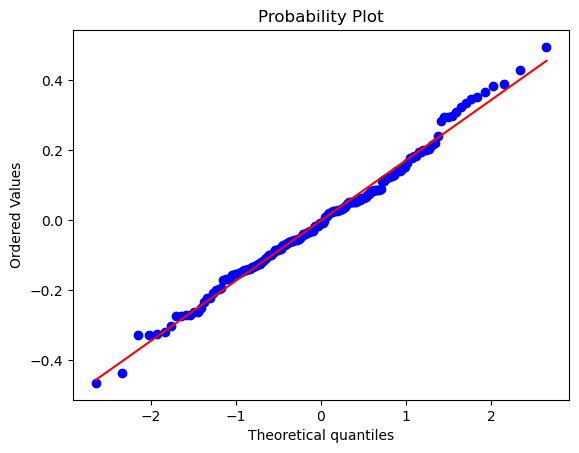

In [95]:
# QQ Plot
stats.probplot(residuals, dist = "norm", plot = pylab)
plt.show()

Um gráfico qq é útil para verificar se os dados seguem uma distribuição específica, como a distribuição normal. Se os dados seguirem uma distribuição normal, os pontos no gráfico qq devem seguir uma linha diagonal. Se os pontos não seguirem uma linha diagonal, isso pode indicar que os dados não seguem uma distribuição normal.

**Análise:**

Os resíduos seguem praticamente uma distribuição normal. A suposição estaria satisfeita. Vamos aplicar o Teste de Shapiro-Wilk aos resíduos para confirmar.

In [96]:
# Função
def valida_sup_4(residuos):
    
    from scipy.stats import shapiro
    
    # Aplica o teste
    resultado = shapiro(residuos)
    
    # Extrai o valor-p
    pval = resultado.pvalue
    
    print('Valor-p =', pval)
    
    if pval < 0.05:
        print("Rejeitamos a H0. Isso indica que há evidências de que os resíduos não seguem uma distribuição normal!")
    else:
        print("Falhamos em rejeitar a H0. Isso indica que os resíduos seguem uma distribuição normal. Suposição satisfeita!")

In [97]:
valida_sup_4(residuals)

Valor-p = 0.3811979806060973
Falhamos em rejeitar a H0. Isso indica que os resíduos seguem uma distribuição normal. Suposição satisfeita!


## Conclusão

Com as suposições satisfeitas, o modelo é estatisticamente robusto e está pronto para fornecer conclusões seguras sobre os fatores que impactam o lucro líquido.

In [98]:
# Coeficientes (o que o modelo aprendeu)
modelo_v3.params

const    5.195737
x1       0.128019
x2      -0.071716
x3       0.101602
dtype: float64

In [99]:
# Vamos criar um dataframe com os coeficientes
df = pd.DataFrame(modelo_v3.params)

In [100]:
df

,0
const,5.195737
x1,0.128019
x2,-0.071716
x3,0.101602


In [101]:
# Lista de colunas com os nomes das variáveis
colunas = ['const',
           'km_rodados',
           'preco_combustivel_litro',
           'faturamento_total']

In [102]:
# Pivot da tabela
novo_df = pd.pivot_table(df, columns = colunas).reset_index()

In [103]:
novo_df

,index,const,faturamento_total,km_rodados,preco_combustivel_litro
0,0,5.195737,0.101602,0.128019,-0.071716


**Interpretação dos Coeficientes**

* **const (5.195737):** Este é o intercepto do modelo. Representa o valor esperado do logaritmo do lucro líquido quando os quilômetros rodados, o preço do combustível e o faturamento total são iguais a zero. No contexto real, funciona apenas como um ajuste matemático da linha de regressão.

* **km_rodados (0.128019):** Para cada unidade de aumento nos quilômetros rodados, espera-se que o lucro (em escala logarítmica) aumente em 0.128019 unidades. Isso indica uma relação positiva, sugerindo que o volume de rodagem contribui diretamente para o ganho final.

* **preco_combustivel_litro (-0.071716):** Para cada unidade de aumento no preço do litro do combustível, espera-se que o lucro diminua em 0.071716 unidades. Este coeficiente confirma o impacto negativo direto dos custos operacionais sobre a rentabilidade.

* **faturamento_total (0.101602):** Para cada unidade de aumento no faturamento total bruto, espera-se que o lucro aumente em 0.101602 unidades. Isso mostra que, após controlar as outras variáveis, o aumento na receita bruta se traduz consistentemente em ganho líquido.

## Respondendo a Pergunta de Negócio:

Com base nos critérios acima, podemos determinar que todas as variáveis (x1 a x3) são relevantes para o modelo. Essas variáveis correspondem a:

* km_rodados
* preco_combustivel_litro
* faturamento_total

Essas variáveis são determinantes para explicar o lucro líquido diário de um motorista de aplicativo, de acordo com a análise dos dados fornecidos.

In [104]:
%reload_ext watermark
%watermark -a "Douglas Vittori"

Author: Douglas Vittori



In [105]:
#%watermark -v -m

In [106]:
%watermark --iversions

matplotlib : 3.10.0
numpy      : 2.3.2
pandas     : 2.3.1
scipy      : 1.15.3
seaborn    : 0.13.2
sklearn    : 1.6.1
statsmodels: 0.14.4



# Fim